In [9]:
# For generating face landmarks data of image dataset and save to preprocessed_dataset folder
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import mediapipe as mp

# Load the FaceMesh model
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6)

# Define constants
# BATCH_SIZE = 32
# IMG_SIZE = (224, 224)
YAWN_DATASET = 'datasets\\Drowsiness_dataset'
CWE_DATASET = 'datasets\\CEW'
PREPROCESSED_DIR = 'PREPROCESSED_DATASET'

# Define the data generators for training and validation sets
# train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Preprocess images and save them to a new directory
# train_dir_preprocessed = os.path.join(PREPROCESSED_DIR, 'train')
if not os.path.exists(PREPROCESSED_DIR):
    os.makedirs(PREPROCESSED_DIR)

for subdir in ['no_yawn', 'yawn']:
    src_dir = os.path.join(YAWN_DATASET, subdir)
    dst_dir = os.path.join(PREPROCESSED_DIR, subdir)

    if not os.path.exists(dst_dir):
        os.makedirs(dst_dir)

    for filename in os.listdir(src_dir):
        img_path = os.path.join(src_dir, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(img)
        if(results.multi_face_landmarks==None):
            continue
        # Convert mesh to numpy array and save
        mesh = np.array([[p.x, p.y, p.z] for face in results.multi_face_landmarks for p in face.landmark])
        mean = np.mean(mesh, axis=0)
        std = np.std(mesh, axis=0)
        mesh_normalized = (mesh - mean) / std
        mesh.shape
        mesh_path = os.path.join(dst_dir, filename[:-4] + '.npy')
        np.save(mesh_path, mesh_normalized)
    print(dst_dir," : ",len(os.listdir(dst_dir)))

for subdir in ['ClosedFace', 'OpenFace']:
    src_dir = os.path.join(CWE_DATASET, subdir)
    dst_dir = os.path.join(PREPROCESSED_DIR, subdir)

    if not os.path.exists(dst_dir):
        os.makedirs(dst_dir)

    for filename in os.listdir(src_dir):
        img_path = os.path.join(src_dir, filename)
        img = cv2.imread(img_path)
        if(img is not None):
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(img)
            if(results.multi_face_landmarks==None):
                continue
            # Convert mesh to numpy array and save
            mesh = np.array([[p.x, p.y, p.z] for face in results.multi_face_landmarks for p in face.landmark])
            mean = np.mean(mesh, axis=0)
            std = np.std(mesh, axis=0)
            mesh_normalized = (mesh - mean) / std
            mesh_path = os.path.join(dst_dir, filename[:-4] + '.npy')
            np.save(mesh_path, mesh_normalized)
    print(dst_dir," : ",len(os.listdir(dst_dir)))


PREPROCESSED_DATASET\no_yawn  :  633
PREPROCESSED_DATASET\yawn  :  632
PREPROCESSED_DATASET\ClosedFace  :  1182
PREPROCESSED_DATASET\OpenFace  :  1231


In [10]:
# For loading face landmarks and yawn labels
import numpy as np
import os

# Set the paths to the yawn and no_yawn folders
yawn_path = "PREPROCESSED_DATASET/yawn/"
no_yawn_path = "PREPROCESSED_DATASET/no_yawn/"
open_eye_path = "PREPROCESSED_DATASET/OpenFace/"
closed_eye_path = "PREPROCESSED_DATASET/ClosedFace/"

# Load the npy files from the yawn folder and store them in a list
yawn_data = []
for file in os.listdir(yawn_path):
    if file.endswith(".npy"):
        filepath = os.path.join(yawn_path, file)
        data = np.load(filepath)
        yawn_data.append((data, 1))  # Store the data and its class

# Load the npy files from the no_yawn folder and store them in a list
no_yawn_data = []
for file in os.listdir(no_yawn_path):
    if file.endswith(".npy"):
        filepath = os.path.join(no_yawn_path, file)
        data = np.load(filepath)
        no_yawn_data.append((data, 0))  # Store the data and its class

open_eye_data = []
for file in os.listdir(open_eye_path):
    if file.endswith(".npy"):
        filepath = os.path.join(open_eye_path, file)
        data = np.load(filepath)
        open_eye_data.append((data, 0))  # Store the data and its class

closed_eye_data = []
for file in os.listdir(closed_eye_path):
    if file.endswith(".npy"):
        filepath = os.path.join(closed_eye_path, file)
        data = np.load(filepath)
        closed_eye_data.append((data, 1))  # Store the data and its class

# Combine the yawn and no_yawn data and shuffle it
# data = open_eye_data + closed_eye_data
data = yawn_data + no_yawn_data + open_eye_data + closed_eye_data
np.random.shuffle(data)

# Extract the data and classes separately
X = [d[0] for d in data]  # List of data
y = [d[1] for d in data]  # List of classes

print("Number of Yawn samples : ",len(yawn_data))
print("Number of No Yawn samples : ",len(no_yawn_data))
print("Number of Open Eye samples : ",len(open_eye_data))
print("Number of Closed Eye samples : ",len(closed_eye_data))
print("Total Number of samples : ",len(data))


Number of Yawn samples :  632
Number of No Yawn samples :  633
Number of Open Eye samples :  1231
Number of Closed Eye samples :  1182
Total Number of samples :  3678


In [13]:
# For training model using preprocessed data
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Dropout

# Split the data into training and validation sets
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# Define the model architecture
model = Sequential([
    Flatten(input_shape=X_train[0].shape),
    Dense(64, activation='relu',),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model with binary cross-entropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer=tf.optimizers.Adam(0.0008), metrics=['accuracy'])

# model.load_weights("yawnDetector.h5")


In [14]:

# Train the model on the training data
history = model.fit(np.array(X_train), np.array(y_train), batch_size=16, epochs=50, validation_data=(np.array(X_val), np.array(y_val)),shuffle=True)

Epoch 1/50
184/184 [==============================] - 2s 6ms/step - loss: 0.6795 - accuracy: 0.5608 - val_loss: 0.6649 - val_accuracy: 0.5761
Epoch 2/50
184/184 [==============================] - 1s 5ms/step - loss: 0.6431 - accuracy: 0.6210 - val_loss: 0.6642 - val_accuracy: 0.5571
Epoch 3/50
184/184 [==============================] - 1s 5ms/step - loss: 0.6256 - accuracy: 0.6336 - val_loss: 0.6082 - val_accuracy: 0.6576
Epoch 4/50
184/184 [==============================] - 1s 5ms/step - loss: 0.6044 - accuracy: 0.6479 - val_loss: 0.5761 - val_accuracy: 0.6929
Epoch 5/50
184/184 [==============================] - 1s 5ms/step - loss: 0.5953 - accuracy: 0.6584 - val_loss: 0.5951 - val_accuracy: 0.6522
Epoch 6/50
184/184 [==============================] - 1s 4ms/step - loss: 0.5727 - accuracy: 0.6747 - val_loss: 0.5521 - val_accuracy: 0.6875
Epoch 7/50
184/184 [==============================] - 1s 4ms/step - loss: 0.5686 - accuracy: 0.6846 - val_loss: 0.5447 - val_accuracy: 0.7092
Epoch 

In [15]:
import pickle
with open('trainHistoryDict', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

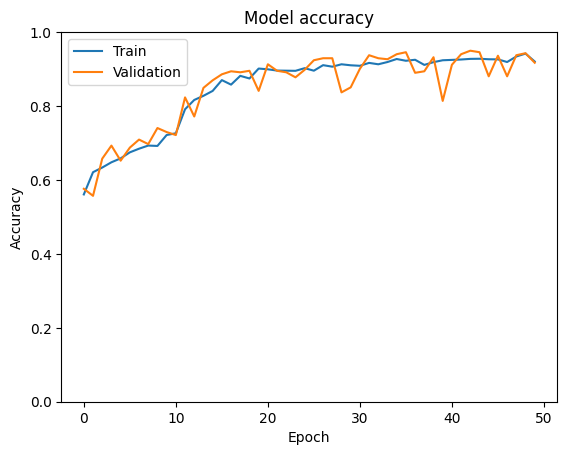

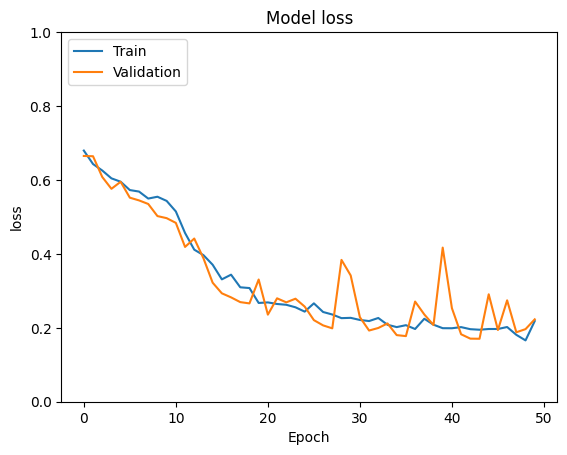

In [25]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
with open('trainHistoryDict', "rb") as file_pi:
    historyData = pickle.load(file_pi)
plt.plot(historyData['accuracy'])
plt.plot(historyData['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.ylim([0,1])
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
plt.plot(historyData['loss'])
plt.plot(historyData['val_loss'])
plt.title('Model loss')
plt.ylim([0,1])
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

23/23 [==============================] - 0s 3ms/step


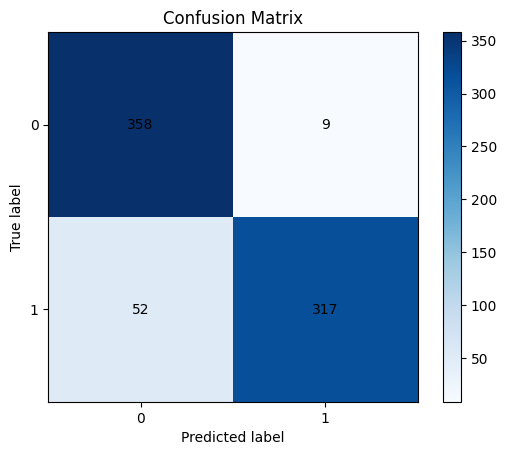

In [22]:
# import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# make predictions on the validation set
y_pred = model.predict(np.array(X_val))
y_pred = (y_pred > 0.5).astype(int)

# calculate the confusion matrix
cm = np.zeros((2,2))
for i in range(len(y_val)):
    cm[y_val[i], y_pred[i]] += 1

# plot the confusion matrix
plt.imshow(cm, cmap='Blues')
plt.xticks([0,1], ['0', '1'])
plt.yticks([0,1], ['0', '1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.colorbar()

# add the counts to the cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(int(cm[i,j])), ha='center', va='center', color='black')

plt.show()

In [17]:
model.save("DrowsinessDetector.h5")

In [ ]:
# For realtime testing of yawn detection model

import cv2
import mediapipe as mp
import numpy as np
#Face Mesh
 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Normalization


# Define the model architecture
model = Sequential([
    Flatten(input_shape=(478,3)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='sigmoid')
])
model.load_weights("DrowsinessDetector.h5")
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh()
cap = cv2.VideoCapture(0)

while(1):
    _,frame = cap.read()
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = face_mesh.process(img)
    if(result.multi_face_landmarks!=None):
        # Convert mesh to numpy array and save
        mesh = np.array([[p.x, p.y, p.z] for face in result.multi_face_landmarks for p in face.landmark])
        mean = np.mean(mesh, axis=0)
        std = np.std(mesh, axis=0)
        mesh_normalized = (mesh - mean) / std
        p = model.predict(np.array([mesh_normalized]),verbose=0)
        # print(p)
        if(p[0][0]<p[0][1]):
            print("Drowsy"+str(p[0][0]*100)+"%")
            cv2.putText(frame,"Drowsy : "+str(int(p[0][1]*100))+"%",(50,50),cv2.FONT_HERSHEY_SIMPLEX,1,(255,0,0))
        else:
            print("Not Drowsy"+str(p[0][0]*100)+"%")
    cv2.imshow(".",frame)

        # if(p[0][0]>p[0][1]):
        #     print("Yawning"+str(p[0][0]*100)+"%")
        # if(p[0][3]>p[0][2]):
        #     print("Closed Eyes"+str(p[0][2]*100)+"%")
    cv2.waitKey(1)

In [23]:
X_train[0].shape

(478, 3)

In [24]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 1434)              0         
                                                                 
 dense_9 (Dense)             (None, 64)                91840     
                                                                 
 dense_10 (Dense)            (None, 16)                1040      
                                                                 
 dense_11 (Dense)            (None, 1)                 17        
                                                                 
Total params: 92,897
Trainable params: 92,897
Non-trainable params: 0
_________________________________________________________________
